#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### Defining functions

In [2]:
def f(x):
    return np.sin(x)

def df_true(x):
    return np.cos(x)


def deriv_forward(f,x,h):
    return (f(x+h)-f(x-h))/h


def deriv_central(f,x,h):
    return (f(x+h) - f(x-h))/(2*h)

x0 = 1.0

print("true:", df_true(x0))
print("forward  h=1e-5:", deriv_forward(f, x0, 1e-5))
print("central  h=1e-5:", deriv_central(f, x0, 1e-5))

true: 0.5403023058681398
forward  h=1e-5: 1.0806046117139978
central  h=1e-5: 0.5403023058569989


###  Calculated Forward and Central difference errors 

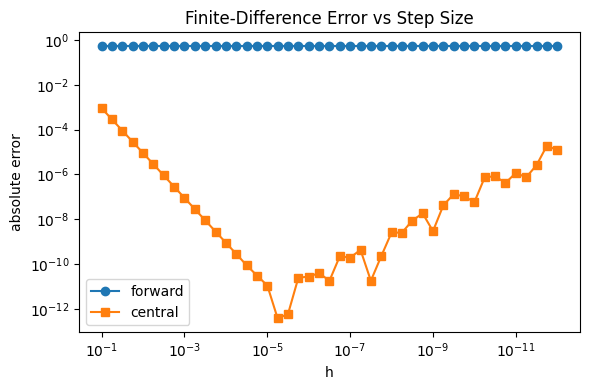

best h, forward: 0.1
best h, central: 5.623413251903491e-06


In [3]:
hs = np.logspace(-1, -12, 45)

err_fwd = np.array([
    abs(deriv_forward(f, x0, h) - df_true(x0))
    for h in hs
])

err_ctr = np.array([
    abs(deriv_central(f, x0, h) - df_true(x0))
    for h in hs
])


plt.figure(figsize=(6, 4))
plt.loglog(hs, err_fwd, "o-", label="forward")
plt.loglog(hs, err_ctr, "s-", label="central")
plt.gca().invert_xaxis()

plt.xlabel("h")
plt.ylabel("absolute error")
plt.legend()
plt.title("Finite-Difference Error vs Step Size")
plt.tight_layout()
plt.show()

print("best h, forward:", hs[np.argmin(err_fwd)])
print("best h, central:", hs[np.argmin(err_ctr)])



#### Test

In [4]:
assert abs(
    deriv_central(f, x0, 1e-5) - df_true(x0)
) < 1e-7

print("Task 1 OK")

Task 1 OK


****


**Which method gives a smaller error near its optimal h?** 
 
central limit because its more accurate that the forward method

**Why does the error eventually increase when h becomes extremely small?**

The error eventually increases when h becomes extremely small because floating-point round-off errors begin to dominate and overwhelm the decreasing truncation errors

**Why is the central-difference method generally more accurate than the forward-difference method?**

The reason is just that a Central Difference scheme is designed to remove more terms in the Taylor Series expansion compared to the Forward Difference, in turn reducing truncation error.

****

### Task 2 - Gradient of Scalar Function

In [5]:
rng = np.random.default_rng(0)


def f(w):
    return w[0]**2 + 3*w[0]*w[1] + 2*w[1]**2


def grad_analytic(w):
    df_dw0 = 2*w[0] + 3*w[1]
    df_dw1 = 3*w[0] + 4*w[1] 
    return np.array([df_dw0, df_dw1])


def numeric_gradient(f, w, h=1e-5):

    g = np.zeros_like(w, dtype=float)

    for i in range(len(w)):

        w_plus = w.copy()
        w_minus = w.copy()
        
        w_plus[i] += h
        w_minus[i] -= h
        g[i] = (f(w_plus) - f(w_minus)) / (2*h)
        
    return g


w = np.array([1.0, 2.0])

ga = grad_analytic(w)
gn = numeric_gradient(f, w)

print("f(w)          =", f(w))
print("analytic grad =", ga)
print("numeric grad  =", gn)

print(
    "max abs diff =",
    np.max(np.abs(ga - gn))
)


eps = 1e-3

d_grad = ga / np.linalg.norm(ga)

gain_grad = f(w + eps * d_grad) - f(w)

gains_random = []

for _ in range(20):

    d = rng.normal(size=2)
    d /= np.linalg.norm(d)

    gains_random.append(
        f(w + eps * d) - f(w)
    )

print("gain along gradient :", gain_grad)
print("best random gain    :", max(gains_random))


assert np.allclose(ga, [8.0, 11.0])
assert np.max(np.abs(ga - gn)) < 1e-6

assert gain_grad >= max(gains_random) - 1e-9

print("Task 2 OK")


f(w)          = 15.0
analytic grad = [ 8. 11.]
numeric grad  = [ 8. 11.]
max abs diff = 1.1647038888895622e-10
gain along gradient : 0.013604551589814662
best random gain    : 0.013554948328849292
Task 2 OK


****

**What is the difference between a derivative and a gradient?**

Derivative: Rate of change of a scalar function with respect to a single scalar variable. Typically written f′(x) or df/dx. Applicable to functions f: R → R.
Gradient: Vector of partial derivatives of a scalar function with respect to several variables. Written ∇f or ∇f(x) = (∂f/∂x1, ∂f/∂x2, …). Applicable to functions f: R^n → R.

**Why do we use .copy() when creating w_plus and w_minus?**

Because the numpy arrays are mutable and if we didnt use .copy() then we would assign and w.plus and w.minus to the same variable, and also we would just change the variable w itself..copy() gives you an independent array so you can safely perturb.

**Why must we perturb one coordinate at a time when calculating the gradient?**

Because a partial derivative is defined as the rate of change holding all other variables fixed. If you moved multiple coordinates simultaneously, the resulting change in f would be a mix of several partials' effects (plus cross terms), and you couldn't isolate how much came from coordinate i alone. One-at-a-time perturbation is what makes the finite-difference formula correspond to a genuine partial derivative

**What does it mean that the gradient points in the direction of steepest ascent?**
The gradient vector points in the direction where a function increases most rapidly



****

### Task 3 — The Chain Rule: By Hand and in Code

In [8]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def forward(w, b, x, y):

    z = w*x + b       
    a = sigmoid(z)       
    L = (a-y)**2       

    return z, a, L


def grad_analytic(w, b, x, y):

    z, a, L = forward(w, b, x, y)

    dL_da = 2 * (a-y) 
    da_dz = a * (1-a)
    dz_dw = x 
    dz_db = 1

    dL_dw = dL_da * da_dz * dz_dw
    dL_db = dL_da * da_dz * dz_db

    return dL_dw, dL_db


def numeric_gradient_wb(w, b, x, y, h=1e-5):
    ndw = (forward(w + h, b, x, y)[2] - forward(w - h, b, x, y)[2]) / (2 * h)
    ndb = (forward(w, b + h, x, y)[2] - forward( w, b - h, x, y )[2]) / (2 * h)

    return ndw, ndb


x, y = 2.0, 1.0
w, b = 0.3, -0.1

z, a, L = forward(w, b, x, y)
print("z, a, L =", z, a, L)

dL_dw, dL_db = grad_analytic(w, b, x, y)
print("analytic dL/dw, dL/db =", dL_dw, dL_db)

ndw, ndb = numeric_gradient_wb(w, b, x, y)
print("numeric  dL/dw, dL/db =", ndw, ndb)

assert abs(dL_dw - ndw) < 1e-6
assert abs(dL_db - ndb) < 1e-6

print("Task 3 OK")

z, a, L = 0.5 0.6224593312018546 0.1425369565965509
analytic dL/dw, dL/db = -0.35489383469854746 -0.17744691734927373
numeric  dL/dw, dL/db = -0.3548938347003316 -0.1774469173501658
Task 3 OK



**What is the chain rule doing in this example?**

To basically minimite the loss functionn and in otder to do that we can use derivatives with respect to W and bias, but it would be daunting, thats why we use chain rule

**Why does the gradient contain several factors multiplied together?**

Because we use chain rule in order to find the each derivative which is going to help us to calculate and find gradient
We just make it more sensitive 

**Why is dL/dw exactly twice dL/db for these particular values?**

L/dw and dL/db share the same dL/da · da/dz factor -- the only difference is dz/dw = x vs dz/db = 1. So dL/dw / dL/db = x. Since x = 2.0 here, dL/dw is exactly twice dL/db.

**Why is numerical gradient checking useful?**

So, its basically used to kinda debug and check if you calculated your gradient correctly and it uses finite differences



### Task 4 — Forward Pass of a Tiny Linear Model

In [ ]:
X = np.array([
    [1.0, 2.0],
    [2.0, 0.5],
    [3.0, 1.0],
    [4.0, 3.0],
])

y = np.array([1.0, 3.0, 5.0, -2.0])

w = np.array([2.0, -1.0])   # shape (2,)
b = 0.5

def predict(X, w, b):


    return X @ w + b

yhat = predict(X, w, b)
print("yhat shape:", yhat.shape)
print("yhat      :", yhat)

# --- Now deliberately introduce a shape bug ---


w_bad = w.reshape(2, 1)   # shape (2, 1) instead of (2,)

yhat_bad = X @ w_bad + b
print("yhat_bad shape:", yhat_bad.shape)
print("yhat_bad      :", yhat_bad)

assert yhat.shape == (4,)
assert yhat_bad.shape == (4, 1)

print("Task 4 OK")